In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
data = pd.read_excel('RSSI_readings.xlsx')

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1325 entries, 0 to 1324
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Time      1325 non-null   object 
 1   Beacon 1  1325 non-null   int64  
 2   Beacon 2  1276 non-null   float64
 3   Beacon 3  1325 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 41.5+ KB


In [83]:
data.head()

,Time,Beacon 1,Beacon 2,Beacon 3
0,2026-04-15 17:22:48.598000,-70,-85.0,-51
1,2026-04-15 17:22:48.450000,-64,-72.0,-54
2,2026-04-15 17:22:48.364000,-72,-73.0,-53
3,2026-04-15 17:22:48.318000,-71,-88.0,-53
4,2026-04-15 17:22:48.271000,-62,-66.0,-53


In [84]:
data['Time'] = pd.to_datetime(data['Time'], errors='coerce')

In [85]:
data['Time'].isna().sum()

np.int64(1269)

In [86]:
data['Time'] = data['Time'].astype(str)


data['Time'] = data['Time'].apply(
    lambda x: x if '2026' in x else '2026-04-15 ' + x
)


data['Time'] = pd.to_datetime(data['Time'], errors='coerce')


print(data['Time'].isna().sum())

1269


In [87]:
data = data.sort_values('Time').reset_index(drop=True)

In [88]:
beacon_cols = ['Beacon 1','Beacon 2','Beacon 3']

data[beacon_cols] = data[beacon_cols].interpolate(method='linear')

 # It fills missing RSSI values by drawing a straight line between known values.

In [89]:
beacon_cols = ['Beacon 1','Beacon 2','Beacon 3']

data[beacon_cols] = data[beacon_cols].rolling(window=3).mean()

# removes sensor noise 

In [90]:
data = data.dropna().reset_index(drop=True)

In [91]:
print(data.dtypes)

Time        datetime64[ns]
Beacon 1           float64
Beacon 2           float64
Beacon 3           float64
dtype: object


In [92]:
features = data.drop(columns=['Time'], errors='ignore')
features = features.select_dtypes(include=['number'])

#drops non numeric features of dimensionality reduction

In [93]:
data['movement_intensity'] = data[beacon_cols].diff().abs().sum(axis=1)
data['movement_intensity'] = data['movement_intensity'].fillna(0)

#How much did the entire signal environment change compared to the previous moment
#difference between the previous values and the next values

In [94]:
X = data[beacon_cols].copy()

# Add dynamics features
X['B1_B2'] = data['Beacon 1'] - data['Beacon 2']
X['B1_B3'] = data['Beacon 1'] - data['Beacon 3']
X['B2_B3'] = data['Beacon 2'] - data['Beacon 3']

X['movement_intensity'] = data['movement_intensity']

#Which beacon is stronger relative to the others?


In [95]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embedding = pca.fit_transform(X)

data['PC1'] = embedding[:, 0]
data['PC2'] = embedding[:, 1]

In [96]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
data['cluster'] = kmeans.fit_predict(X)

#unsupervised clustering on your BLE feature space to group similar signal patterns together.


In [97]:
data.head(5)

,Time,Beacon 1,Beacon 2,Beacon 3,movement_intensity,PC1,PC2,cluster
0,2026-04-15 17:22:44.905,-61.666667,-72.666667,-52.000000,0.0,-4.440140,6.262889,0
1,2026-04-15 17:22:44.998,-63.333333,-70.666667,-54.333333,6.0,1.329556,1.974922,2
2,2026-04-15 17:22:45.086,-64.000000,-70.666667,-54.666667,1.0,1.307195,1.314755,2
3,2026-04-15 17:22:45.130,-65.333333,-72.000000,-52.333333,5.0,-3.722220,0.235528,2
4,2026-04-15 17:22:45.177,-63.666667,-68.000000,-50.000000,8.0,-3.580851,-3.775790,2


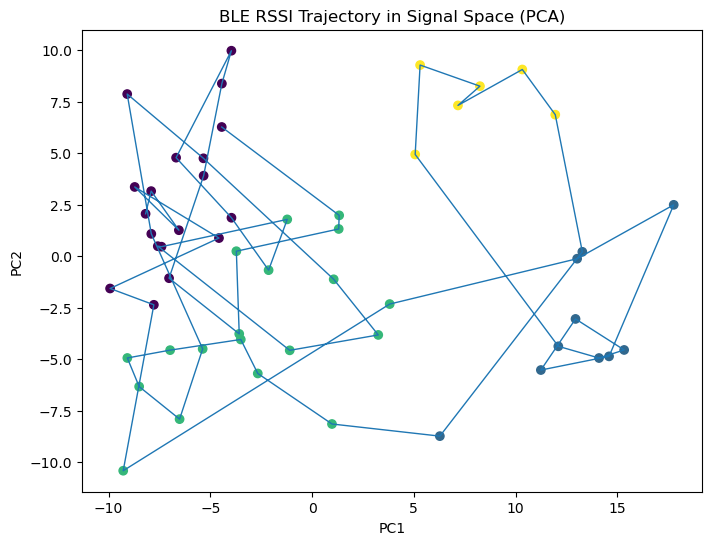

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(data['PC1'], data['PC2'], linewidth=1)
plt.title("BLE RSSI Trajectory in Signal Space (PCA)")
plt.scatter(data['PC1'], data['PC2'], c=data['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#How your BLE signal state moves through a compressed 2D representation over time.
#

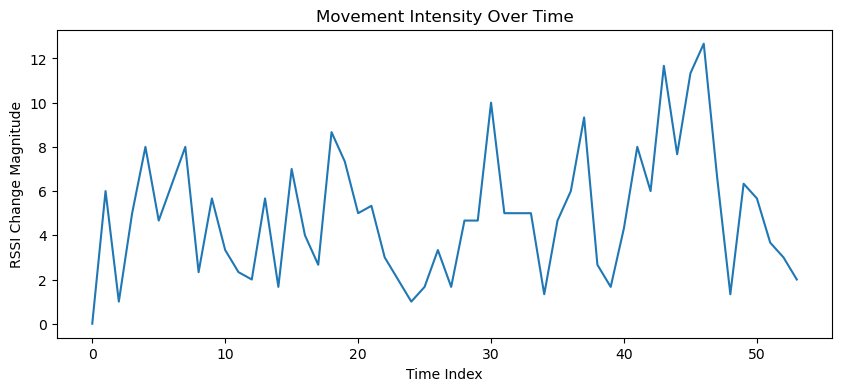

In [99]:
plt.figure(figsize=(10,4))
plt.plot(data['movement_intensity'])
plt.title("Movement Intensity Over Time")
plt.xlabel("Time Index")
plt.ylabel("RSSI Change Magnitude")
plt.show()

#how fast state is changing

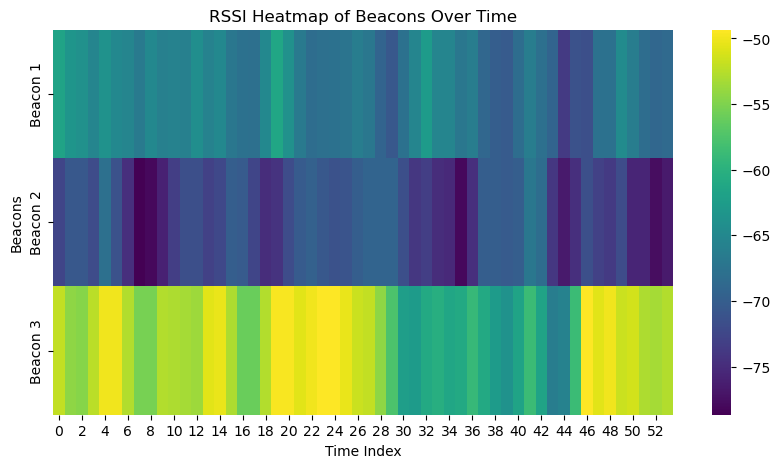

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

beacon_cols = ['Beacon 1', 'Beacon 2', 'Beacon 3']

plt.figure(figsize=(10,5))
sns.heatmap(data[beacon_cols].T, cmap='viridis')

plt.title("RSSI Heatmap of Beacons Over Time")
plt.xlabel("Time Index")
plt.ylabel("Beacons")
plt.show()

#How each beacon’s signal strength changes across samples.

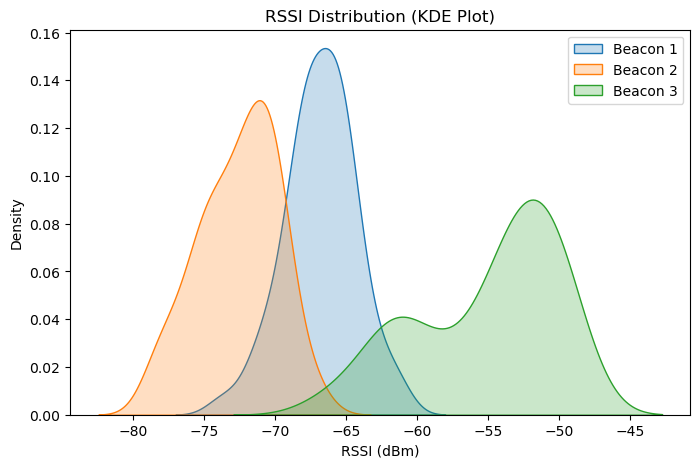

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for col in beacon_cols:
    sns.kdeplot(data[col], label=col, fill=True)

plt.title("RSSI Distribution (KDE Plot)")
plt.xlabel("RSSI (dBm)")
plt.legend()
plt.show()

#probability distribution of RSSI values for each beacon
#ignores time and focuses on signal behavior patterns.
#beacons individually are not strongly distinguishable in raw signal space

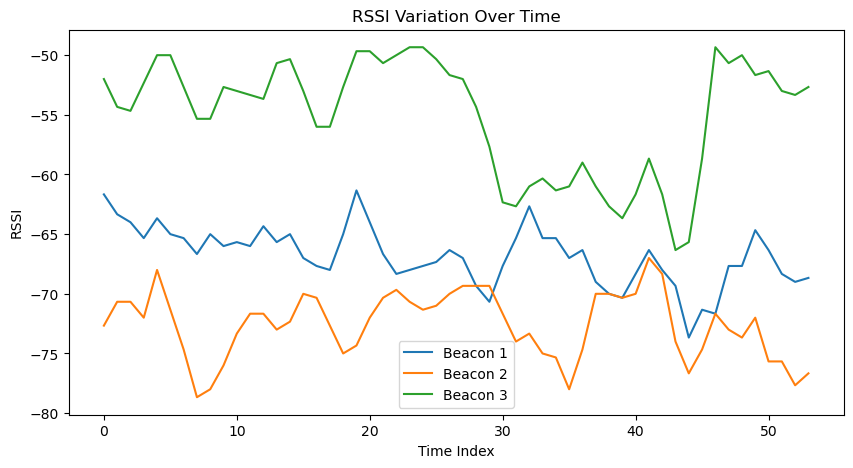

In [102]:
plt.figure(figsize=(10,5))

for col in beacon_cols:
    plt.plot(data[col], label=col)

plt.title("RSSI Variation Over Time")
plt.xlabel("Time Index")
plt.ylabel("RSSI")
plt.legend()
plt.show()

#raw RSSI time series for each beacon over time
#how each beacon’s signal fluctuates over time
